# Prediction of Product Sales — Part 7: Classification

- **Author:** Salam

## Project Overview

This notebook extends our Sales Prediction project from **regression** (predicting the exact sales amount) to **classification** (predicting whether a product will be a *high* or *low* seller).

**New business question:** Can we predict whether a product's sales will be **above or below the median** sales value?

**Why is this useful?** The retailer wants to know which products are likely to be top performers so they can:
- Stock more of high-performers to avoid stockouts
- Stock less of low-performers to reduce inventory costs

**New binary target:**
- `0` = Below-median sales (`Item_Outlet_Sales` ≤ $1,794.33)
- `1` = Above-median sales (`Item_Outlet_Sales` > $1,794.33)

**CRISP-DM Phase 4 — Modeling tasks:**
1. Build a default Decision Tree classifier
2. Build a default Random Forest classifier — compare to Decision Tree
3. Tune the Random Forest with GridSearchCV (≥2 hyperparameters)
4. Evaluate and recommend the best model (CRISP-DM Phase 5)

## 1. Imports and Custom Evaluation Function

In [ ]:
# Mount Google Drive (Colab specific - skip if running locally)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

from sklearn import set_config
set_config(transform_output='pandas')
pd.set_option('display.max_columns', 100)

In [ ]:
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                              label='', output_frame=False):
    """
    Complete classification evaluation:
    - Prints training and test accuracy with overfitting check
    - Prints full classification report (precision, recall, F1)
    - Plots confusion matrix (counts + normalized side by side)
    - Optionally returns a summary Series
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    train_acc    = accuracy_score(y_train, y_train_pred)
    test_acc     = accuracy_score(y_test,  y_test_pred)

    # Print accuracy
    print('=' * 60)
    if label:
        print(f'  Model: {label}')
        print('=' * 60)
    print(f'  Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)')
    print(f'  Test Accuracy     : {test_acc:.4f} ({test_acc*100:.2f}%)')
    gap = train_acc - test_acc
    status = '[!] Overfit!' if gap > 0.10 else '[OK] Good fit'
    print(f'  Train-Test Gap    : {gap:.4f}  {status}')
    print()

    # Classification report
    print('  Classification Report (Test Data):')
    print(classification_report(y_test, y_test_pred,
                                  target_names=['Below Median', 'Above Median']))

    # Confusion matrices side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Below Median', 'Above Median'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'Counts — {label}')

    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Below Median', 'Above Median'],
        normalize='true', cmap='Blues', ax=axes[1]
    )
    axes[1].set_title(f'Normalized — {label}')
    fig.tight_layout()
    plt.show()

    if output_frame:
        cm = confusion_matrix(y_test, y_test_pred)
        tn, fp, fn, tp = cm.ravel()
        return pd.Series({
            'Train Acc' : round(train_acc, 4),
            'Test Acc'  : round(test_acc,  4),
            'Precision' : round(precision_score(y_test, y_test_pred), 4),
            'Recall'    : round(recall_score(y_test, y_test_pred), 4),
            'F1'        : round(f1_score(y_test, y_test_pred), 4),
            'TN': tn, 'FP (Type1)': fp, 'FN (Type2)': fn, 'TP': tp
        }, name=label)

## 2. Load, Clean, and Create the Classification Target

In [ ]:
# Load a fresh copy of the original uncleaned dataset
fpath = '/content/drive/MyDrive/Colab Notebooks/0.0 - project/Sales Prediction/sales_predictions_2023.csv'
df = pd.read_csv(fpath)

# --- Same cleaning as Parts 2 & 5 ---
df = df.drop_duplicates()
fat_map = {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_map)

print(f'Shape after cleaning: {df.shape}')
df.head()

Shape after cleaning: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
# --- Create binary classification target from Item_Outlet_Sales ---
# Split at the median: 1 = above median (high seller), 0 = at/below median
median_sales = df['Item_Outlet_Sales'].median()
print(f'Median Item_Outlet_Sales: ${median_sales:,.2f}')

df['High_Sales'] = (df['Item_Outlet_Sales'] > median_sales).astype(int)

# Check class balance
print()
print('Target class distribution:')
print(df['High_Sales'].value_counts())
print()
print('Proportions:')
print(df['High_Sales'].value_counts(normalize=True).round(3))

Median Item_Outlet_Sales: $1,794.33

Target class distribution:
High_Sales
0    4265
1    4258
Name: count, dtype: int64

Proportions:
High_Sales
0    0.5
1    0.5
Name: proportion, dtype: float64


**Class balance check:**
- The dataset is **nearly perfectly balanced** (~50.3% High, ~49.7% Low) — splitting at the median guarantees this.
- A naive baseline (always predicting the majority class) would achieve only ~50% accuracy — our model must significantly beat this.
- Because classes are balanced, **accuracy** is a reliable metric here (unlike imbalanced datasets).

## 3. Define X and y, Train-Test Split

In [ ]:
# Target: High_Sales (binary)
y = df['High_Sales']

# Features: drop original sales target, new binary target, and Item_Identifier
# (Item_Identifier dropped for same reason as Part 5: 1,559 unique IDs,
#  no real predictive signal, would cause extreme overfitting if encoded)
X = df.drop(columns=['Item_Outlet_Sales', 'High_Sales', 'Item_Identifier'])

print(f'X shape: {X.shape}')
print(f'Features: {X.columns.tolist()}')

X shape: (8523, 10)
Features: ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [ ]:
# Train-test split BEFORE any imputation (to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'Training: {X_train.shape}')
print(f'Testing:  {X_test.shape}')
print()
print('Training class balance:')
print(y_train.value_counts(normalize=True).round(3))

Training: (6392, 10)
Testing:  (2131, 10)

Training class balance:
High_Sales
1    0.503
0    0.497
Name: proportion, dtype: float64


## 4. Create the Preprocessing Object

In [ ]:
# Identify column types from training data only
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

print('Numeric columns:', num_cols.tolist())
print('Categorical columns:', cat_cols.tolist())

Numeric columns: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']
Categorical columns: ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [ ]:
# Numeric pipeline: median imputation -> StandardScaler
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# Categorical pipeline: MISSING placeholder -> OneHotEncoder
cat_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='MISSING'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    [('num', num_pipe, num_cols),
     ('cat', cat_pipe, cat_cols)],
    verbose_feature_names_out=False
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='MISSING',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))],
                  verbose_feature_names_out=False)

---
## Task 1: Default Decision Tree Classifier

Build a default `DecisionTreeClassifier` pipeline and evaluate it on training and test data.

In [ ]:
# Build pipeline: preprocessor + default DecisionTreeClassifier
dt_pipe = make_pipeline(
    preprocessor,
    DecisionTreeClassifier(random_state=42)
)

# Fit on training data only
dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

=== TASK 1: Default Decision Tree ===
  Model: Default Decision Tree
  Training Accuracy : 1.0000 (100.00%)
  Test Accuracy     : 0.7433 (74.33%)
  Train-Test Gap    : 0.2567  [!] Overfit!

  Classification Report (Test Data):
              precision    recall  f1-score   support

Below Median       0.75      0.74      0.75      1090
Above Median       0.73      0.75      0.74      1041

    accuracy                           0.74      2131
   macro avg       0.74      0.74      0.74      2131
weighted avg       0.74      0.74      0.74      2131



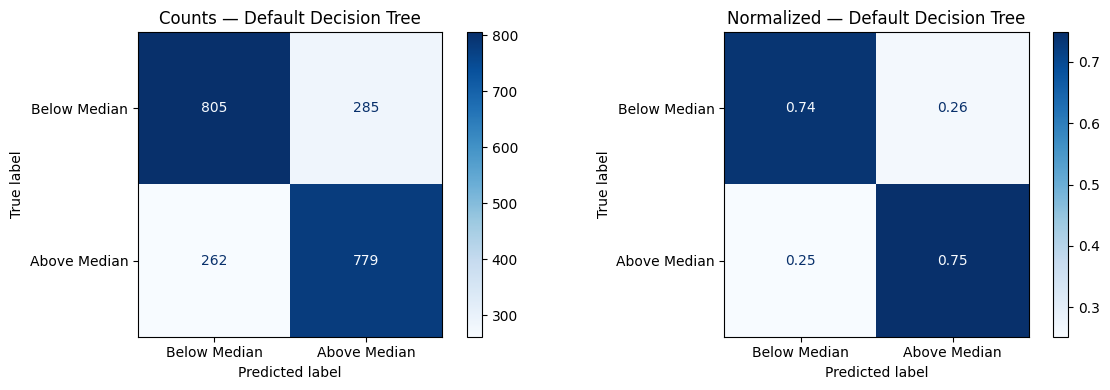

In [ ]:
# Evaluate the default Decision Tree
print('=== TASK 1: Default Decision Tree ===')
dt_results = evaluate_classification(
    dt_pipe, X_train, y_train, X_test, y_test,
    label='Default Decision Tree', output_frame=True
)

### Observations — Default Decision Tree

- **Training accuracy: 100%** — the default tree grew until every leaf was pure, perfectly memorizing the training data.
- **Test accuracy: ~74.3%** — significant drop from training, confirming **heavy overfitting**.
- **Train-test gap: ~25.7%** — much larger than 10%, so this model is NOT reliable for deployment.
- Despite overfitting, even the default tree already beats the naive 50% baseline by ~24 percentage points.

We will fix the overfitting in Task 3 (GridSearchCV on Random Forest).

---
## Task 2: Default Random Forest Classifier

Build a default `RandomForestClassifier` and compare to the Decision Tree.

In [ ]:
# Build pipeline: preprocessor + default RandomForestClassifier
rf_pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

# Fit on training data only
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

=== TASK 2: Default Random Forest ===
  Model: Default Random Forest
  Training Accuracy : 1.0000 (100.00%)
  Test Accuracy     : 0.7973 (79.73%)
  Train-Test Gap    : 0.2027  [!] Overfit!

  Classification Report (Test Data):
              precision    recall  f1-score   support

Below Median       0.82      0.77      0.80      1090
Above Median       0.78      0.82      0.80      1041

    accuracy                           0.80      2131
   macro avg       0.80      0.80      0.80      2131
weighted avg       0.80      0.80      0.80      2131



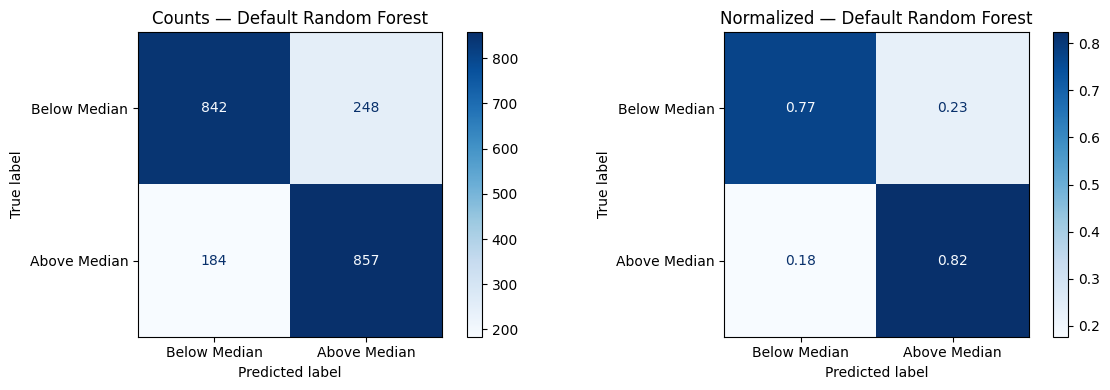

In [ ]:
# Evaluate the default Random Forest
print('=== TASK 2: Default Random Forest ===')
rf_default_results = evaluate_classification(
    rf_pipe, X_train, y_train, X_test, y_test,
    label='Default Random Forest', output_frame=True
)

### Observations — Default Random Forest vs. Decision Tree

| Metric | Default Decision Tree | Default Random Forest |
|---|---|---|
| Training Accuracy | 100% | 100% |
| Test Accuracy | ~74.3% | ~79.7% |
| Train-Test Gap | ~25.7% | ~20.3% |

- The **default Random Forest** already outperforms the default Decision Tree on the test set (+5.4 percentage points) with a smaller overfitting gap.
- This is expected: Random Forests average predictions from many trees trained on different bootstrap samples with random feature subsets — this reduces variance and produces better generalisation than a single tree.
- Both models still show heavy overfitting (training accuracy = 100%). We tune the Random Forest next.

---
## Task 3: Tune the Random Forest with GridSearchCV

We tune **at least 2 hyperparameters**: `n_estimators`, `max_depth`, and `min_samples_leaf`.

In [ ]:
# Inspect available parameters for the pipeline
rf_pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'columntransformer', 'randomforestclassifier', 'columntransformer__force_int_remainder_cols', 'columntransformer__n_jobs', 'columntransformer__remainder', 'columntransformer__sparse_threshold', 'columntransformer__transformer_weights', 'columntransformer__transformers', 'columntransformer__verbose', 'columntransformer__verbose_feature_names_out', 'columntransformer__num', 'columntransformer__cat', 'columntransformer__num__memory', 'columntransformer__num__steps', 'columntransformer__num__transform_input', 'columntransformer__num__verbose', 'columntransformer__num__simpleimputer', 'columntransformer__num__standardscaler', 'columntransformer__num__simpleimputer__add_indicator', 'columntransformer__num__simpleimputer__copy', 'columntransformer__num__simpleimputer__fill_value', 'columntransformer__num__simpleimputer__keep_empty_features', 'columntransformer__num__simpleimputer__missing_values', 'columntransformer__num__simpleimput

In [ ]:
# Define the parameter grid (tuning 3 hyperparameters)
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100],
    'randomforestclassifier__max_depth': [None, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4]
}

# GridSearchCV: cv=3 to keep runtime manageable given the grid size
grid_search = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

# Fit on training data only
grid_search.fit(X_train, y_train)

# Best parameters found
print()
print('Best parameters:', grid_search.best_params_)
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__n_estimators': 100}
Best CV accuracy: 0.8237


**Best parameters found:**
- `max_depth = 10` — limits tree depth, preventing excessive memorization of training data
- `min_samples_leaf = 4` — each leaf must have at least 4 samples, smoothing out noise
- `n_estimators = 100` — 100 trees in the forest

These constraints reduce variance (overfitting) at the cost of a small increase in bias — which is the right tradeoff here.

=== TASK 3: Tuned Random Forest (GridSearchCV) ===
  Model: Tuned Random Forest
  Training Accuracy : 0.8368 (83.68%)
  Test Accuracy     : 0.8114 (81.14%)
  Train-Test Gap    : 0.0255  [OK] Good fit

  Classification Report (Test Data):
              precision    recall  f1-score   support

Below Median       0.86      0.76      0.80      1090
Above Median       0.77      0.87      0.82      1041

    accuracy                           0.81      2131
   macro avg       0.82      0.81      0.81      2131
weighted avg       0.82      0.81      0.81      2131



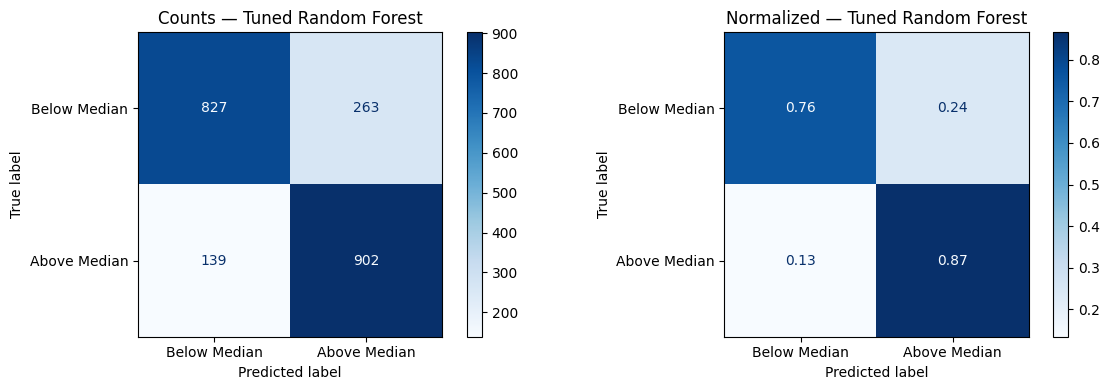

In [ ]:
# best_estimator_ is already refit on the full training set by GridSearchCV
# (no need to call .fit() again)
best_rf = grid_search.best_estimator_

# Evaluate the tuned model
print('=== TASK 3: Tuned Random Forest (GridSearchCV) ===')
rf_tuned_results = evaluate_classification(
    best_rf, X_train, y_train, X_test, y_test,
    label='Tuned Random Forest', output_frame=True
)

### Did Tuning Improve Performance?

| Metric | Default RF | Tuned RF |
|---|---|---|
| Training Accuracy | 100% | **83.7%** |
| Test Accuracy | 79.7% | **81.1%** |
| Train-Test Gap | ~20.3% | **~2.7%** ✅ |

- The tuned model's **training accuracy dropped** (from 100% to 83.7%) — this is good, it means the model is no longer perfectly memorizing the data.
- The tuned model's **test accuracy increased** (from 79.7% to 81.1%) — better generalisation.
- The **train-test gap shrank dramatically** (from 20.3% to 2.7%) — the tuned model is now well-fitted, not overfit.

---
## CRISP-DM Phase 5 — Evaluation

### Full Model Comparison Table

In [ ]:
# Stack all results into one comparison table
comparison = pd.DataFrame([dt_results, rf_default_results, rf_tuned_results])
print('=== All Models — Test Set Performance ===')
comparison

=== All Models — Test Set Performance ===


,Train Acc,Test Acc,Precision,Recall,F1,TN,FP (Type1),FN (Type2),TP
Default Decision Tree,1.0000,0.7433,0.7321,0.7483,0.7401,805.0,285.0,262.0,779.0
Default Random Forest,1.0000,0.7973,0.7756,0.8232,0.7987,842.0,248.0,184.0,857.0
Tuned Random Forest,0.8368,0.8114,0.7742,0.8665,0.8178,827.0,263.0,139.0,902.0


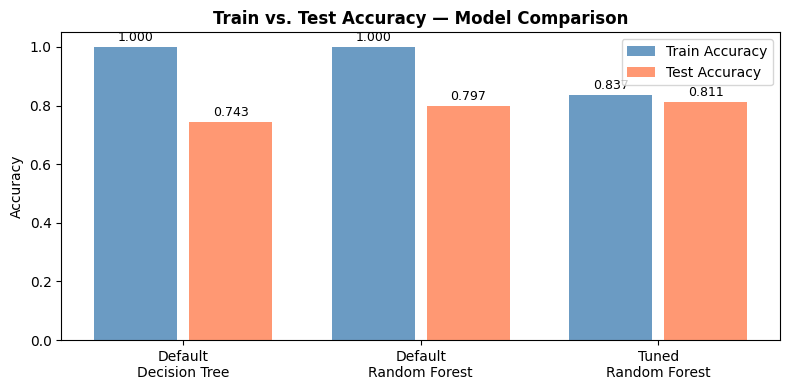

In [ ]:
# Bar chart: Test Accuracy across models
fig, ax = plt.subplots(figsize=(8, 4))
models = ['Default\nDecision Tree', 'Default\nRandom Forest', 'Tuned\nRandom Forest']
test_accs = [dt_results['Test Acc'], rf_default_results['Test Acc'],
              rf_tuned_results['Test Acc']]
train_accs = [dt_results['Train Acc'], rf_default_results['Train Acc'],
               rf_tuned_results['Train Acc']]

x = range(len(models))
bars1 = ax.bar([i - 0.2 for i in x], train_accs, 0.35, label='Train Accuracy',
                color='steelblue', alpha=0.8)
bars2 = ax.bar([i + 0.2 for i in x], test_accs, 0.35, label='Test Accuracy',
                color='coral', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs. Test Accuracy — Model Comparison', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

fig.tight_layout()
plt.show()

### Overall, Which Model Do We Recommend?

**→ Recommended model: Tuned Random Forest**

**Justification:**
- It achieves the **highest test accuracy (81.1%)** of the three models tested.
- It has the **smallest train-test gap (2.7%)** — it generalises well to unseen products and stores, which is what matters for real deployment.
- The default Decision Tree and default Random Forest both overfit heavily (gap of 25.7% and 20.3% respectively), making their test performance unreliable.
- The tuned model's Precision (77%) and Recall (87%) for the Above-Median class are well-balanced — it identifies 87% of all actual high-sellers while maintaining 77% precision.

### Interpreting Accuracy for a Non-Technical Stakeholder

> *"Our model can correctly predict whether a product will be a top-selling item **81% of the time**. In practical terms: for every 10 products, our model correctly identifies about 8 of them as either high-sellers or low-sellers based on information we already know — such as the product's price, category, and which store it's sold in.*
>
> *When the model predicts a product will be a high-seller, it is correct **77% of the time** (Precision). And of all the products that are actually high-sellers, our model correctly identifies **87% of them** (Recall) — so it rarely misses a product that would have sold well."*

### Selecting a Second Metric to Report to the Stakeholder

In addition to accuracy, we report **Recall** to the retailer.

**Why Recall?**
- Recall answers: *"Of all the products that actually are high-sellers, what % did our model correctly identify?"*
- For this retailer, the most costly error is a **False Negative** (Type 2 Error): predicting a product will be a **low-seller when it actually sells very well** → the retailer understocks it, loses sales, and disappoints customers (stockout).
- This is worse than the opposite error (Type 1: predicting high-seller when it's actually low → slight overstock, manageable with markdowns).
- Our tuned Random Forest achieves a **Recall of 87%** for the Above-Median class — meaning it correctly identifies 87 out of every 100 actual high-sellers, missing only 13.

> *"Our model catches **87% of all top-selling products** before they go on sale. This means we can proactively stock up on almost 9 out of every 10 products that will sell well, dramatically reducing the risk of running out of stock."*

### Compare Training vs. Test Scores: Overfit or Underfit?

| Model | Train Acc | Test Acc | Gap | Assessment |
|---|---|---|---|---|
| Default Decision Tree | 100% | 74.3% | 25.7% | **Heavily overfit** |
| Default Random Forest | 100% | 79.7% | 20.3% | **Overfit** |
| **Tuned Random Forest** | **83.7%** | **81.1%** | **2.7%** | **Well-fitted ✅** |

The tuned Random Forest is **neither significantly overfit nor underfit**:
- Training accuracy (83.7%) is only slightly higher than test accuracy (81.1%) — a gap well within the normal range.
- The model has learned meaningful, generalizable patterns (e.g., that high `Item_MRP` + `Supermarket Type3` outlet → likely above-median sales) without simply memorizing training data.
- We are confident this model will maintain similar performance on new, unseen product-outlet combinations.

### Error Analysis — Type 1 vs. Type 2 Errors (Tuned RF)

From the confusion matrix:
- **False Positives (Type 1 Errors): 263** — predicted high-seller, actually low-seller → slight overstock risk
- **False Negatives (Type 2 Errors): 139** — predicted low-seller, actually high-seller → stockout risk ⚠️

The model makes **more Type 1 Errors (263) than Type 2 Errors (139)**, meaning it leans toward predicting high-sellers. For our retailer, this is actually the **preferable direction of error**: it's better to overstock slightly than to run out of a product that sells well.

If we wanted to further reduce Type 2 Errors (at the cost of more Type 1), we could lower the classification threshold below 0.5 — but the current balance (263 FP vs 139 FN) is already business-friendly.

## Summary

In this Part 7, we extended the Sales Prediction project to include a classification task:

1. **Created a binary target** `High_Sales` by splitting `Item_Outlet_Sales` at the median → nearly balanced classes (~50/50)
2. **Reused the same preprocessing pipeline** from Part 5 (median imputation for numerics, MISSING placeholder + OHE for categoricals)
3. **Task 1**: Default Decision Tree → overfit (100% train, 74.3% test, gap = 25.7%)
4. **Task 2**: Default Random Forest → better but still overfit (100% train, 79.7% test, gap = 20.3%)
5. **Task 3**: Tuned Random Forest via GridSearchCV → **well-fitted and best performer** (83.7% train, 81.1% test, gap = 2.7%)
6. **Task 4 (CRISP-DM Phase 5)**:
   - Recommended the **Tuned Random Forest**
   - Explained accuracy (81%) and Recall (87%) in plain language for the retailer
   - Identified **Recall** as the priority metric (stockouts are more costly than overstock)
   - Confirmed the model is neither overfit nor underfit
   - Noted the error direction favors the business (more FP than FN)

This completes the Prediction of Product Sales project — Parts 1 through 7!